# Instrumental Variables in Practice: Does College Education Raise Wages?

This notebook walks through a complete, real-world **Instrumental Variables (IV)** analysis using a classic dataset from labor economics.

**Research question:** What is the causal effect of an additional year of education on hourly wages?

**The problem:** People who get more education differ from those who don't in ways we can't fully observe — ambition, family background, innate ability. These confounders bias a naive regression of wages on education.

**The solution:** David Card (1995) proposed using **growing up near a 4-year college** as an instrument for education. The idea: living near a college lowers the cost/friction of attending, which shifts how much education someone gets — but proximity to a college, by itself, shouldn't directly raise your wages.

| Concept | Variable in this dataset |
|---|---|
| Outcome (Y) | `lwage` — log hourly wage in 1976 |
| Treatment (X) | `educ` — years of completed schooling |
| Instrument (Z) | `nearc4` — grew up in a county with a 4-year college |
| Confounders (U) | Unobserved: ability, motivation, family wealth |

**Dataset:** National Longitudinal Survey of Young Men (NLSYM), n = 3,010. This is *the* textbook IV dataset, used in Card (1995), Angrist & Pischke's *Mostly Harmless Econometrics*, and Cunningham's *Causal Inference: The Mixtape*. We pull it directly from the open-source [Rdatasets](https://github.com/vincentarelbundock/Rdatasets) mirror of the `causaldata` R package.


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from linearmodels.iv import IV2SLS

sns.set_style("whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:.4f}")


## 2. Load the Data

We load the data directly from the public GitHub mirror of the `causaldata` R package (no API key or download needed). If you don't have internet access in your environment, download the CSV once and point `pd.read_csv` at the local file instead.

In [2]:
url = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/causaldata/close_college.csv"
df = pd.read_csv(url)
df = df.drop(columns=["rownames"])
df.head()


,nearc4,educ,black,smsa,south,married,exper,lwage
0,0,7,1,1,0,1.0000,16,6.3063
1,0,12,0,1,0,1.0000,9,6.1759
2,0,12,0,1,0,1.0000,16,6.5806
3,1,11,0,1,0,1.0000,10,5.5215
4,1,12,0,1,0,1.0000,16,6.5917


In [3]:
print(f"Shape: {df.shape}")
df.info()


Shape: (3010, 8)
<class 'pandas.DataFrame'>
RangeIndex: 3010 entries, 0 to 3009
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   nearc4   3010 non-null   int64  
 1   educ     3010 non-null   int64  
 2   black    3010 non-null   int64  
 3   smsa     3010 non-null   int64  
 4   south    3010 non-null   int64  
 5   married  3003 non-null   float64
 6   exper    3010 non-null   int64  
 7   lwage    3010 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 188.3 KB


**Variable dictionary:**

- `nearc4` — instrument: 1 if there was a 4-year college in the person's home county
- `educ` — treatment: years of completed schooling
- `lwage` — outcome: log hourly wage in 1976
- `black`, `south`, `smsa`, `married` — demographic/geographic controls
- `exper` — years of work experience

A handful of rows are missing `married`; we'll drop those (under 0.3% of the sample, so this won't meaningfully affect results).

In [4]:
df = df.dropna(subset=["married"]).reset_index(drop=True)
df["expersq"] = df["exper"] ** 2   # quadratic term, standard in wage regressions
print(f"Final analytic sample: {df.shape[0]} observations")
df.describe()


Final analytic sample: 3003 observations


,nearc4,educ,black,smsa,south,married,exper,lwage,expersq
count,3003.0000,3003.0000,3003.0000,3003.0000,3003.0000,3003.0000,3003.0000,3003.0000,3003.0000
mean,0.6830,13.2664,0.2328,0.7133,0.4039,2.2714,8.8575,6.2621,95.6014
std,0.4654,2.6772,0.4227,0.4523,0.4908,2.0668,4.1415,0.4437,84.6277
min,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,4.6052,0.0000
25%,0.0000,12.0000,0.0000,0.0000,0.0000,1.0000,6.0000,5.9801,36.0000
50%,1.0000,13.0000,0.0000,1.0000,0.0000,1.0000,8.0000,6.2879,64.0000
75%,1.0000,16.0000,0.0000,1.0000,1.0000,4.0000,11.0000,6.5632,121.0000
max,1.0000,18.0000,1.0000,1.0000,1.0000,6.0000,23.0000,7.7849,529.0000


## 3. Why Not Just Run OLS?

The naive approach: regress wages directly on education. The problem is **omitted variable bias** — anything correlated with both education and wages (like ability) gets absorbed into the education coefficient, inflating it.

In [5]:
ols_naive = smf.ols("lwage ~ educ", data=df).fit()
print(ols_naive.summary())


                            OLS Regression Results                            
Dep. Variable:                  lwage   R-squared:                       0.099
Model:                            OLS   Adj. R-squared:                  0.099
Method:                 Least Squares   F-statistic:                     329.5
Date:                Wed, 17 Jun 2026   Prob (F-statistic):           6.02e-70
Time:                        04:03:55   Log-Likelihood:                -1663.8
No. Observations:                3003   AIC:                             3332.
Df Residuals:                    3001   BIC:                             3344.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.5706      0.039    143.334      0.0

In [6]:
ols_controls = smf.ols(
    "lwage ~ educ + exper + expersq + black + south + smsa + married",
    data=df
).fit()
print(ols_controls.summary())


                            OLS Regression Results                            
Dep. Variable:                  lwage   R-squared:                       0.313
Model:                            OLS   Adj. R-squared:                  0.312
Method:                 Least Squares   F-statistic:                     195.2
Date:                Wed, 17 Jun 2026   Prob (F-statistic):          5.65e-239
Time:                        04:03:55   Log-Likelihood:                -1255.9
No. Observations:                3003   AIC:                             2528.
Df Residuals:                    2995   BIC:                             2576.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.9022      0.069     71.219      0.0

Adding controls drops the OLS coefficient from about 0.077 to roughly 0.07 log-wage points per year of schooling. But this is **still likely biased** — we can't observe or control for ability, motivation, or family wealth directly. We need a source of variation in education that is unrelated to these unobserved factors.

## 4. The Instrument: College Proximity

Card's insight: growing up near a 4-year college (`nearc4`) plausibly shifts how much education someone gets — without directly affecting their wages.

For this to be a valid instrument, it needs to satisfy three conditions:

1. **Relevance** — `nearc4` actually predicts `educ` (testable)
2. **Exclusion restriction** — `nearc4` affects `lwage` *only* through `educ`, not directly (not directly testable, requires argument)
3. **Independence** — `nearc4` is uncorrelated with unobserved confounders, i.e. roughly "as good as random" conditional on controls (not directly testable, requires argument)

Let's visualize the two empirical legs of this: does the instrument move the treatment, and does it move the outcome?

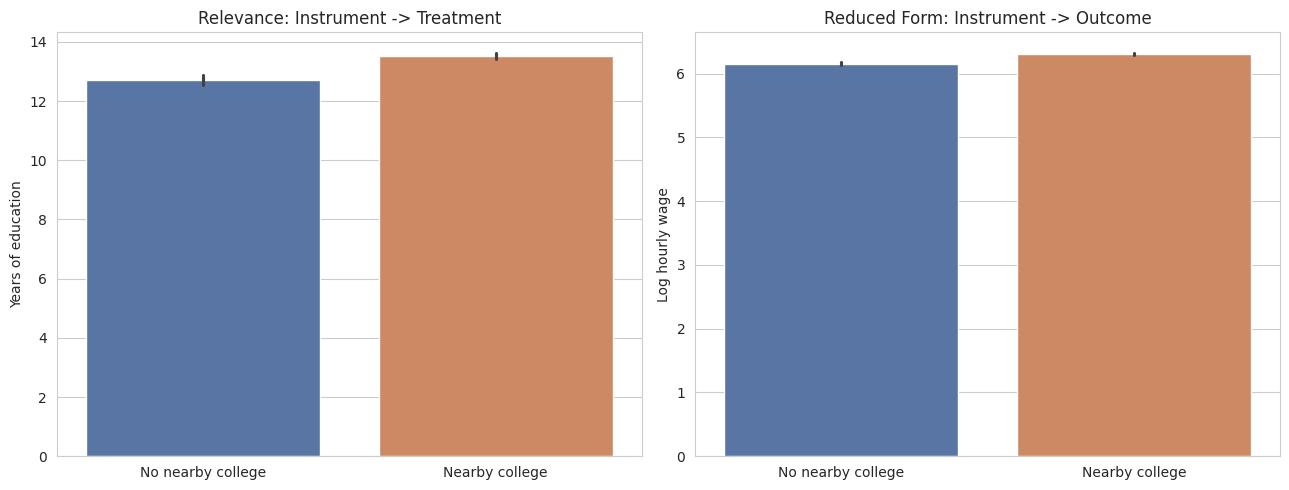

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(x="nearc4", y="educ", data=df, hue="nearc4", ax=axes[0],
            palette=["#4C72B0", "#DD8452"], errorbar=("ci", 95), legend=False)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["No nearby college", "Nearby college"])
axes[0].set_ylabel("Years of education")
axes[0].set_xlabel("")
axes[0].set_title("Relevance: Instrument -> Treatment")

sns.barplot(x="nearc4", y="lwage", data=df, hue="nearc4", ax=axes[1],
            palette=["#4C72B0", "#DD8452"], errorbar=("ci", 95), legend=False)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["No nearby college", "Nearby college"])
axes[1].set_ylabel("Log hourly wage")
axes[1].set_xlabel("")
axes[1].set_title("Reduced Form: Instrument -> Outcome")

plt.tight_layout()
plt.show()


Both bars move in the expected direction: people who grew up near a college get more education on average, and also earn somewhat more. The question IV answers is: **how much of that wage gap is explained by the extra schooling, as opposed to other differences between these two groups?**

## 5. Step 1 — First Stage: Does the Instrument Predict the Treatment?

The first stage regresses the treatment (`educ`) on the instrument (`nearc4`) plus controls. We want this relationship to be strong — a "weak instrument" leads to unreliable IV estimates.

In [8]:
first_stage = smf.ols(
    "educ ~ nearc4 + exper + expersq + black + south + smsa + married",
    data=df
).fit()
print(first_stage.summary())


                            OLS Regression Results                            
Dep. Variable:                   educ   R-squared:                       0.478
Model:                            OLS   Adj. R-squared:                  0.476
Method:                 Least Squares   F-statistic:                     391.0
Date:                Wed, 17 Jun 2026   Prob (F-statistic):               0.00
Time:                        04:03:56   Log-Likelihood:                -6243.1
No. Observations:                3003   AIC:                         1.250e+04
Df Residuals:                    2995   BIC:                         1.255e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     16.9469      0.189     89.604      0.0

In [9]:
# Partial F-test: does nearc4 add explanatory power beyond the controls alone?
restricted = smf.ols(
    "educ ~ exper + expersq + black + south + smsa + married",
    data=df
).fit()

f_stat, p_value, df_diff = first_stage.compare_f_test(restricted)
print(f"Partial F-statistic on the instrument: {f_stat:.2f}")
print(f"P-value: {p_value:.6f}")
print()
print("Rule of thumb: F > 10 suggests the instrument is not 'weak'.")
print("Here F is just above that threshold -- a reasonably strong, though not",
      "overwhelmingly powerful, instrument. This is a known feature of this",
      "dataset, and one reason later IV literature treats single proximity",
      "instruments with some caution.")


Partial F-statistic on the instrument: 15.75
P-value: 0.000074

Rule of thumb: F > 10 suggests the instrument is not 'weak'.
Here F is just above that threshold -- a reasonably strong, though not overwhelmingly powerful, instrument. This is a known feature of this dataset, and one reason later IV literature treats single proximity instruments with some caution.


The coefficient on `nearc4` (~0.33) means: holding other factors constant, growing up near a 4-year college is associated with about a third of a year more schooling. The F-statistic is just above the conventional "not weak" threshold of 10 — strong enough to proceed, but a good reminder that IV estimates can be noisy when the instrument's pull on the treatment is modest.

## 6. Step 2 — Reduced Form: Does the Instrument Predict the Outcome?

This is the *total* effect of the instrument on wages — combining (a) the instrument's effect on education and (b) education's effect on wages.

In [10]:
reduced_form = smf.ols(
    "lwage ~ nearc4 + exper + expersq + black + south + smsa + married",
    data=df
).fit()
print(reduced_form.summary())


                            OLS Regression Results                            
Dep. Variable:                  lwage   R-squared:                       0.217
Model:                            OLS   Adj. R-squared:                  0.215
Method:                 Least Squares   F-statistic:                     118.6
Date:                Wed, 17 Jun 2026   Prob (F-statistic):          4.13e-154
Time:                        04:03:56   Log-Likelihood:                -1452.8
No. Observations:                3003   AIC:                             2922.
Df Residuals:                    2995   BIC:                             2970.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.1048      0.038    159.106      0.0

## 7. The Wald Estimator — Building Intuition

Before running full 2SLS, it's worth seeing the simplest possible version of IV: the **Wald estimator**, using no controls at all.

$$
\hat{\beta}_{IV} = \frac{E[Y \mid Z=1] - E[Y \mid Z=0]}{E[T \mid Z=1] - E[T \mid Z=0]} = \frac{\text{Reduced Form}}{\text{First Stage}}
$$

This is literally "scale the wage gap by the education gap" — it isolates only the portion of the education-wage relationship that's driven by the instrument.

In [11]:
e_y1 = df.loc[df.nearc4 == 1, "lwage"].mean()
e_y0 = df.loc[df.nearc4 == 0, "lwage"].mean()
e_t1 = df.loc[df.nearc4 == 1, "educ"].mean()
e_t0 = df.loc[df.nearc4 == 0, "educ"].mean()

wald_estimate = (e_y1 - e_y0) / (e_t1 - e_t0)

print(f"E[Y | Z=1] = {e_y1:.4f}    E[Y | Z=0] = {e_y0:.4f}")
print(f"E[T | Z=1] = {e_t1:.4f}    E[T | Z=0] = {e_t0:.4f}")
print(f"\nWald (simple IV) estimate: {wald_estimate:.4f}")

naive_ols = smf.ols("lwage ~ educ", data=df).fit().params["educ"]
print(f"Naive OLS estimate (no controls): {naive_ols:.4f}")


E[Y | Z=1] = 6.3111    E[Y | Z=0] = 6.1567
E[T | Z=1] = 13.5290    E[T | Z=0] = 12.7006

Wald (simple IV) estimate: 0.1864
Naive OLS estimate (no controls): 0.0521


Even without any controls, the simple Wald estimate (~0.19) is noticeably larger than naive OLS (~0.05). This is the opposite direction you might initially expect from an "ability bias" story, and it is a well-documented empirical puzzle in this literature — one leading explanation is **measurement error in self-reported schooling**, which biases OLS *toward* zero, an effect IV is known to correct for. This is a good reminder that real data rarely matches a textbook narrative perfectly, and that the *direction* of IV vs. OLS differences should always be reasoned through, not assumed.

## 8. Full 2SLS With Controls

Now let's run the proper Two-Stage Least Squares regression, including the demographic and experience controls, using `linearmodels`. This is the standard, publication-grade way to estimate an IV model.

In [12]:
iv_model = IV2SLS.from_formula(
    "lwage ~ 1 + exper + expersq + black + south + smsa + married + [educ ~ nearc4]",
    data=df
).fit(cov_type="robust")

print(iv_model.summary)


                          IV-2SLS Estimation Summary                          
Dep. Variable:                  lwage   R-squared:                      0.2587
Estimator:                    IV-2SLS   Adj. R-squared:                 0.2570
No. Observations:                3003   F-statistic:                    948.08
Date:                Wed, Jun 17 2026   P-value (F-stat)                0.0000
Time:                        04:03:56   Distribution:                  chi2(7)
Cov. Estimator:                robust                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Intercept      3.9882     0.8386     4.7556     0.0000      2.3445      5.6319
exper          0.0949     0.0223     4.2603     0.00

**Interpretation:** the coefficient on `educ` is the **Local Average Treatment Effect (LATE)** — the causal effect of an additional year of schooling, specifically for the population of **compliers**: people whose education level was actually changed by growing up near a college. It does *not* tell us the effect for "always-takers" (people who'd get a lot of education regardless of college proximity, e.g. due to strong family expectations) or "never-takers" (people who wouldn't pursue higher education even with a college nearby).

## 9. Comparing OLS vs. IV Side by Side

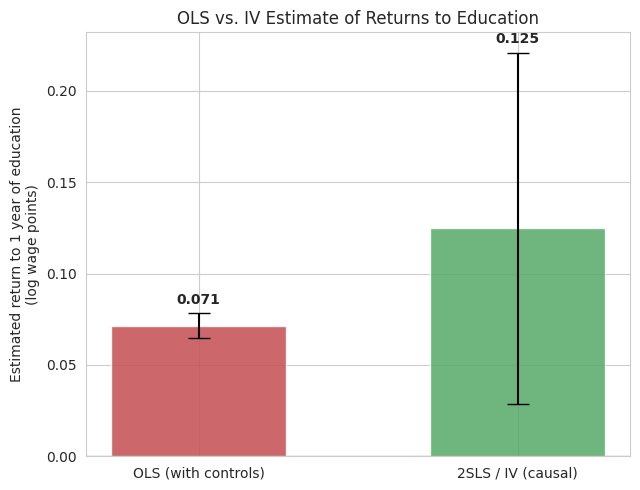

In [13]:
methods = ["OLS (with controls)", "2SLS / IV (causal)"]
coefs = [ols_controls.params["educ"], iv_model.params["educ"]]
errs_95 = [ols_controls.bse["educ"] * 1.96, iv_model.std_errors["educ"] * 1.96]

fig, ax = plt.subplots(figsize=(6.5, 5))
colors = ["#C44E52", "#55A868"]
ax.bar(methods, coefs, yerr=errs_95, capsize=8, color=colors, alpha=0.85, width=0.55)
ax.set_ylabel("Estimated return to 1 year of education\n(log wage points)")
ax.set_title("OLS vs. IV Estimate of Returns to Education")
ax.axhline(0, color="black", linewidth=0.8)
for i, v in enumerate(coefs):
    ax.text(i, v + errs_95[i] + 0.005, f"{v:.3f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()


In [14]:
comparison = pd.DataFrame({
    "Method": ["OLS (no controls)", "OLS (with controls)", "Wald (no controls)", "2SLS / IV (with controls)"],
    "Estimate": [naive_ols, ols_controls.params["educ"], wald_estimate, iv_model.params["educ"]],
    "Std. Error": [
        smf.ols("lwage ~ educ", data=df).fit().bse["educ"],
        ols_controls.bse["educ"],
        np.nan,
        iv_model.std_errors["educ"],
    ],
})
comparison


,Method,Estimate,Std. Error
0,OLS (no controls),0.0521,0.0029
1,OLS (with controls),0.0715,0.0035
2,Wald (no controls),0.1864,NaN
3,2SLS / IV (with controls),0.1249,0.0490


## 10. Diagnostics: Is This a Credible IV Design?

A trustworthy IV analysis reports diagnostics, not just a point estimate. Three checks matter most:

1. **Instrument strength** (already checked above via the partial F-stat)
2. **Endogeneity test** — does education actually need an instrument, or would OLS have been fine?
3. **First-stage fit** — formal summary from the 2SLS object itself

In [15]:
print(iv_model.wu_hausman())


Wu-Hausman test of exogeneity
H0: All endogenous variables are exogenous
Statistic: 1.2504
P-value: 0.2636
Distributed: F(1,2994)


The Wu-Hausman test asks: "if we assume `educ` is exogenous (no instrument needed), is that assumption rejected by the data?" A p-value above 0.05 here means we **fail to reject** exogeneity — i.e., this particular test doesn't give strong evidence that OLS was biased. This may feel anticlimactic, but it's an honest and important part of IV practice: the test has limited power in finite samples, and **the case for using IV here rests primarily on the *theoretical* argument that ability and family background confound the OLS estimate**, not on this single statistical test. Good causal analysis reports this nuance rather than hiding it.

In [16]:
print(iv_model.first_stage)


    First Stage Estimation Results    
                                  educ
--------------------------------------
R-squared                       0.4775
Partial R-squared               0.0052
Shea's R-squared                0.0052
Partial F-statistic             16.543
P-value (Partial F-stat)     4.755e-05
Partial F-stat Distn           chi2(1)
========================== ===========
Intercept                       16.947
                              (105.56)
exper                          -0.4324
                             (-13.409)
expersq                         0.0014
                              (0.8300)
black                          -0.9453
                             (-10.688)
south                          -0.3002
                             (-3.8261)
smsa                            0.4233
                              (4.9763)
married                        -0.0744
                             (-4.2175)
nearc4                          0.3271
                         

## 11. Key Takeaways

- **OLS is likely biased** here because of unobserved confounders like ability and family background that affect both education and wages.
- **`nearc4` (college proximity)** is a plausible instrument: it shifts education (confirmed by a positive, statistically significant first stage) and arguably doesn't affect wages except through education.
- **2SLS estimates a LATE**, not an ATE — specifically, the effect for people whose schooling decision was actually swayed by living near a college. This is *not* necessarily the effect for everyone in the population.
- **Instrument strength matters.** Our partial F-statistic is just above the conventional "not weak" cutoff of 10 — worth flagging in any write-up, since weak instruments can produce large, unstable estimates.
- **Diagnostics tell a fuller story than a single coefficient.** The Wu-Hausman test here didn't strongly confirm OLS bias, which is a useful reminder that IV's value often rests on a *credible causal argument*, not purely on a single statistical test.

### Further reading
- Card, D. (1995). *Using Geographic Variation in College Proximity to Estimate the Return to Schooling.*
- Angrist, J. & Pischke, J-S. *Mostly Harmless Econometrics* (Ch. 4)
- Cunningham, S. *Causal Inference: The Mixtape* — Instrumental Variables chapter
- Facure, M. *Causal Inference for the Brave and True* — Ch. 8 & 9 (Instrumental Variables, Non-Compliance & LATE)
